In [ ]:
%load_ext autoreload
%autoreload 2
import logging
import re
from pathlib import Path
from typing import Any

import geopandas as gpd
import joblib
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.patches import Patch

from ppcluster import load_config, setup_logger

logger = setup_logger(logging.INFO, name="ppcx")

input_dir = Path("output/2020")
output_dir = input_dir / "kinematic_sectors_time_series"

config = load_config()

if not input_dir.exists():
    raise FileNotFoundError(f"Input directory not found: {input_dir}")

output_dir.mkdir(parents=True, exist_ok=True)

UNIT = "px"
UNIT_SCALE = 1.0  # 1 for px, or the m/px conversion factor

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
def find_result_folders(
    base_dir: Path, pattern: str = r".*_\d{4}-\d{2}-\d{2}$"
) -> list[Path]:
    """
    Find result folders matching `pattern` under `base_dir`.

    Args:
        base_dir: directory to scan for result folders
        pattern: regex to match folder names (default: CAMERA_YYYY-MM-DD)

    Returns:
        Sorted list of Path objects for folders that match the pattern.
    """
    folders = []
    date_pattern = re.compile(r"(\d{4}-\d{2}-\d{2})")

    for folder in base_dir.iterdir():
        if not folder.is_dir():
            continue
        if re.match(pattern, folder.name):
            # Extract date from folder name
            match = date_pattern.search(folder.name)
            if match:
                date_str = match.group(1)
                folders.append((date_str, folder))

    # Sort by date
    folders.sort(key=lambda x: x[0])

    # Return only folder paths
    folders = [folder for _, folder in folders]

    return folders


def load_sector_results(
    folder: Path, search_pattern: str | None = None
) -> dict[str, Any] | None:
    """
    Load a single date results bundle from `folder`.

    Args:
        folder: path to a results folder
        search_pattern: glob pattern to find the results bundle (default "*results.joblib")

    Returns:
        Dict with keys "date", "sectors", "stats", "pts_by_sector" on success, None on failure.
    """
    try:
        # Auto-detect base_name from folder if not provided
        if search_pattern is None:
            search_pattern = "*results.joblib"

        # Look for the bundle file
        bundle_files = list(folder.glob(search_pattern))
        if not bundle_files:
            raise FileNotFoundError(f"No bundle file found in {folder}")

        if len(bundle_files) > 1:
            logger.warning(
                f"Multiple bundle files found in {folder}, using the first one"
            )
        bundle_path = bundle_files[0]

        # Load main results bundle
        if not bundle_path.exists():
            raise FileNotFoundError(f"Bundle file not found: {bundle_path}")

        bundle = joblib.load(bundle_path)
        if not isinstance(bundle, dict):
            raise ValueError(f"Invalid bundle format in {bundle_path}")

        # Extract relevant data
        date = bundle.get("reference_date", None)
        sectors = bundle.get("sectors", None)
        pts_by_sector = bundle.get("pts_by_sector", None)

        return {
            "date": date,
            "sectors": sectors,
            "pts_by_sector": pts_by_sector,
        }

    except Exception as exc:
        logger.error(f"Failed to load results from {folder}: {exc}")
        return None


def collect_statistics(
    results_list: list[dict[str, Any] | None],
) -> pd.DataFrame:
    """
    Collect and reorganize time series statistics per sector into a single GeoDataFrame.
    """

    if not results_list:
        logger.warning("collect_statistics: empty results_list")
        return pd.DataFrame()

    frames = []

    for idx, result in enumerate(results_list):
        if not result:
            continue

        date_str = result.get("date")

        # Use the GeoDataFrame 'sectors' which contains stats + geometry
        gdf_sectors = result.get("sectors")

        try:
            date_ts = pd.to_datetime(date_str)
        except Exception:
            logger.error(f"Invalid date: {date_str}")
            continue

        # Work on a copy
        df_daily = gdf_sectors.copy()

        # Ensure 'sector' identifier column exists
        if "sector" not in df_daily.columns:
            raise KeyError("'sector' column not found in sectors GeoDataFrame")

        # Add date column
        df_daily["date"] = date_ts

        # Calculate spatial extents if geometry is available (for swimmer/centroid plots)
        if "geometry" in df_daily.columns:
            # Ensure valid geometries
            valid_geom = df_daily[
                df_daily.geometry.notna() & ~df_daily.geometry.is_empty
            ]
            if not valid_geom.empty:
                # Calculate centroid Y (elevation) and extents
                df_daily["centroid_y"] = df_daily.geometry.centroid.y
                df_daily["min_y"] = df_daily.geometry.bounds.miny
                df_daily["max_y"] = df_daily.geometry.bounds.maxy

        frames.append(df_daily)

    if not frames:
        logger.warning("collect_statistics: no valid frames collected")
        return pd.DataFrame()

    # Concatenate all daily frames
    # pd.concat handles GeoDataFrames correctly if they are uniform
    combined_df = pd.concat(frames, ignore_index=True)

    # Sort for time series plotting
    combined_df = combined_df.sort_values(by=["date", "sector"]).reset_index(drop=True)

    return combined_df


def collect_points_time_series(
    results_list: list[dict[str, Any] | None],
) -> pd.DataFrame:
    """
    Collect point-level data across all dates into a single time series DataFrame.

    Each row represents a single point at a specific date, with columns:
    - date: observation date
    - sector: sector label (A, B, C, D, etc.)
    - x, y: spatial coordinates
    - u, v: velocity components
    - V: velocity magnitude
    - geometry: point geometry
    - cluster_id: cluster membership ID
    - area: associated area

    Args:
        results_list: List of result dictionaries (one per date)

    Returns:
        DataFrame with all points from all dates concatenated and sorted
    """
    if not results_list:
        logger.warning("collect_points_time_series: empty results_list")
        return pd.DataFrame()

    frames = []

    for result in results_list:
        if not result:
            continue

        date_str = result.get("date")
        pts_by_sector = result.get("pts_by_sector")

        if pts_by_sector is None or pts_by_sector.empty:
            continue

        try:
            date_ts = pd.to_datetime(date_str)
        except Exception:
            logger.error(f"Invalid date: {date_str}")
            continue

        # Copy points DataFrame and add date column
        df_points = pts_by_sector.copy()
        df_points["date"] = date_ts

        frames.append(df_points)

    if not frames:
        logger.warning("collect_points_time_series: no valid frames collected")
        return pd.DataFrame()

    # Concatenate all daily point frames
    combined_pts = pd.concat(frames, ignore_index=True)

    # Sort by date and sector for organized output
    combined_pts = combined_pts.sort_values(by=["date", "sector"]).reset_index(
        drop=True
    )

    logger.info(
        f"Collected {len(combined_pts)} points across "
        f"{combined_pts['date'].nunique()} dates and "
        f"{combined_pts['sector'].nunique()} sectors"
    )

    return combined_pts


In [197]:
dir_pattern = r".*_\d{4}-\d{2}-\d{2}$"
results_pattern = "*results.joblib"

# Find result folders
logger.info(f"Searching for result folders in {input_dir}...")
folders = find_result_folders(input_dir, pattern=dir_pattern)
logger.info(f"Found {len(folders)} result folders")

# Load results from all dates
logger.info("Loading results from all dates...")
results_list = []
for folder in folders:
    result = load_sector_results(folder, search_pattern=results_pattern)
    if result is not None:
        results_list.append(result)

logger.info(f"Successfully loaded {len(results_list)} / {len(folders)} results")

# Collect sector statistics into a DataFrame
df_sectors = collect_statistics(results_list)
logger.info(
    f"Successfully loaded {len(df_sectors)} records from {len(df_sectors['date'].unique())} dates"
)

# Collect point-level time series data
df_points_ts = collect_points_time_series(results_list)
columns_to_drop = ["geometry", "cluster_id", "area"]
df_points_ts = df_points_ts.drop(columns=columns_to_drop, errors="ignore")

logger.info(f"Points time series shape: {df_points_ts.shape}")
logger.info(f"Columns: {df_points_ts.columns.tolist()}")

2026-01-22 16:06:15 | [INFO    ] Searching for result folders in output/2020...
2026-01-22 16:06:15 | [INFO    ] Found 152 result folders
2026-01-22 16:06:15 | [INFO    ] Loading results from all dates...
2026-01-22 16:06:15 | [ERROR   ] Failed to load results from output/2020/PPCX_Tele_2020-06-08: No bundle file found in output/2020/PPCX_Tele_2020-06-08
2026-01-22 16:06:15 | [ERROR   ] Failed to load results from output/2020/PPCX_Tele_2020-06-09: No bundle file found in output/2020/PPCX_Tele_2020-06-09
2026-01-22 16:06:15 | [ERROR   ] Failed to load results from output/2020/PPCX_Tele_2020-06-10: No bundle file found in output/2020/PPCX_Tele_2020-06-10


2026-01-22 16:06:15 | [ERROR   ] Failed to load results from output/2020/PPCX_Tele_2020-06-12: No bundle file found in output/2020/PPCX_Tele_2020-06-12
2026-01-22 16:06:15 | [ERROR   ] Failed to load results from output/2020/PPCX_Tele_2020-06-13: No bundle file found in output/2020/PPCX_Tele_2020-06-13
2026-01-22 16:06:16 | [ERROR   ] Failed to load results from output/2020/PPCX_Tele_2020-09-20: No bundle file found in output/2020/PPCX_Tele_2020-09-20
2026-01-22 16:06:16 | [ERROR   ] Failed to load results from output/2020/PPCX_Tele_2020-09-21: No bundle file found in output/2020/PPCX_Tele_2020-09-21
2026-01-22 16:06:16 | [ERROR   ] Failed to load results from output/2020/PPCX_Tele_2020-09-22: No bundle file found in output/2020/PPCX_Tele_2020-09-22
2026-01-22 16:06:16 | [ERROR   ] Failed to load results from output/2020/PPCX_Tele_2020-09-23: No bundle file found in output/2020/PPCX_Tele_2020-09-23
2026-01-22 16:06:16 | [ERROR   ] Failed to load results from output/2020/PPCX_Tele_2020-

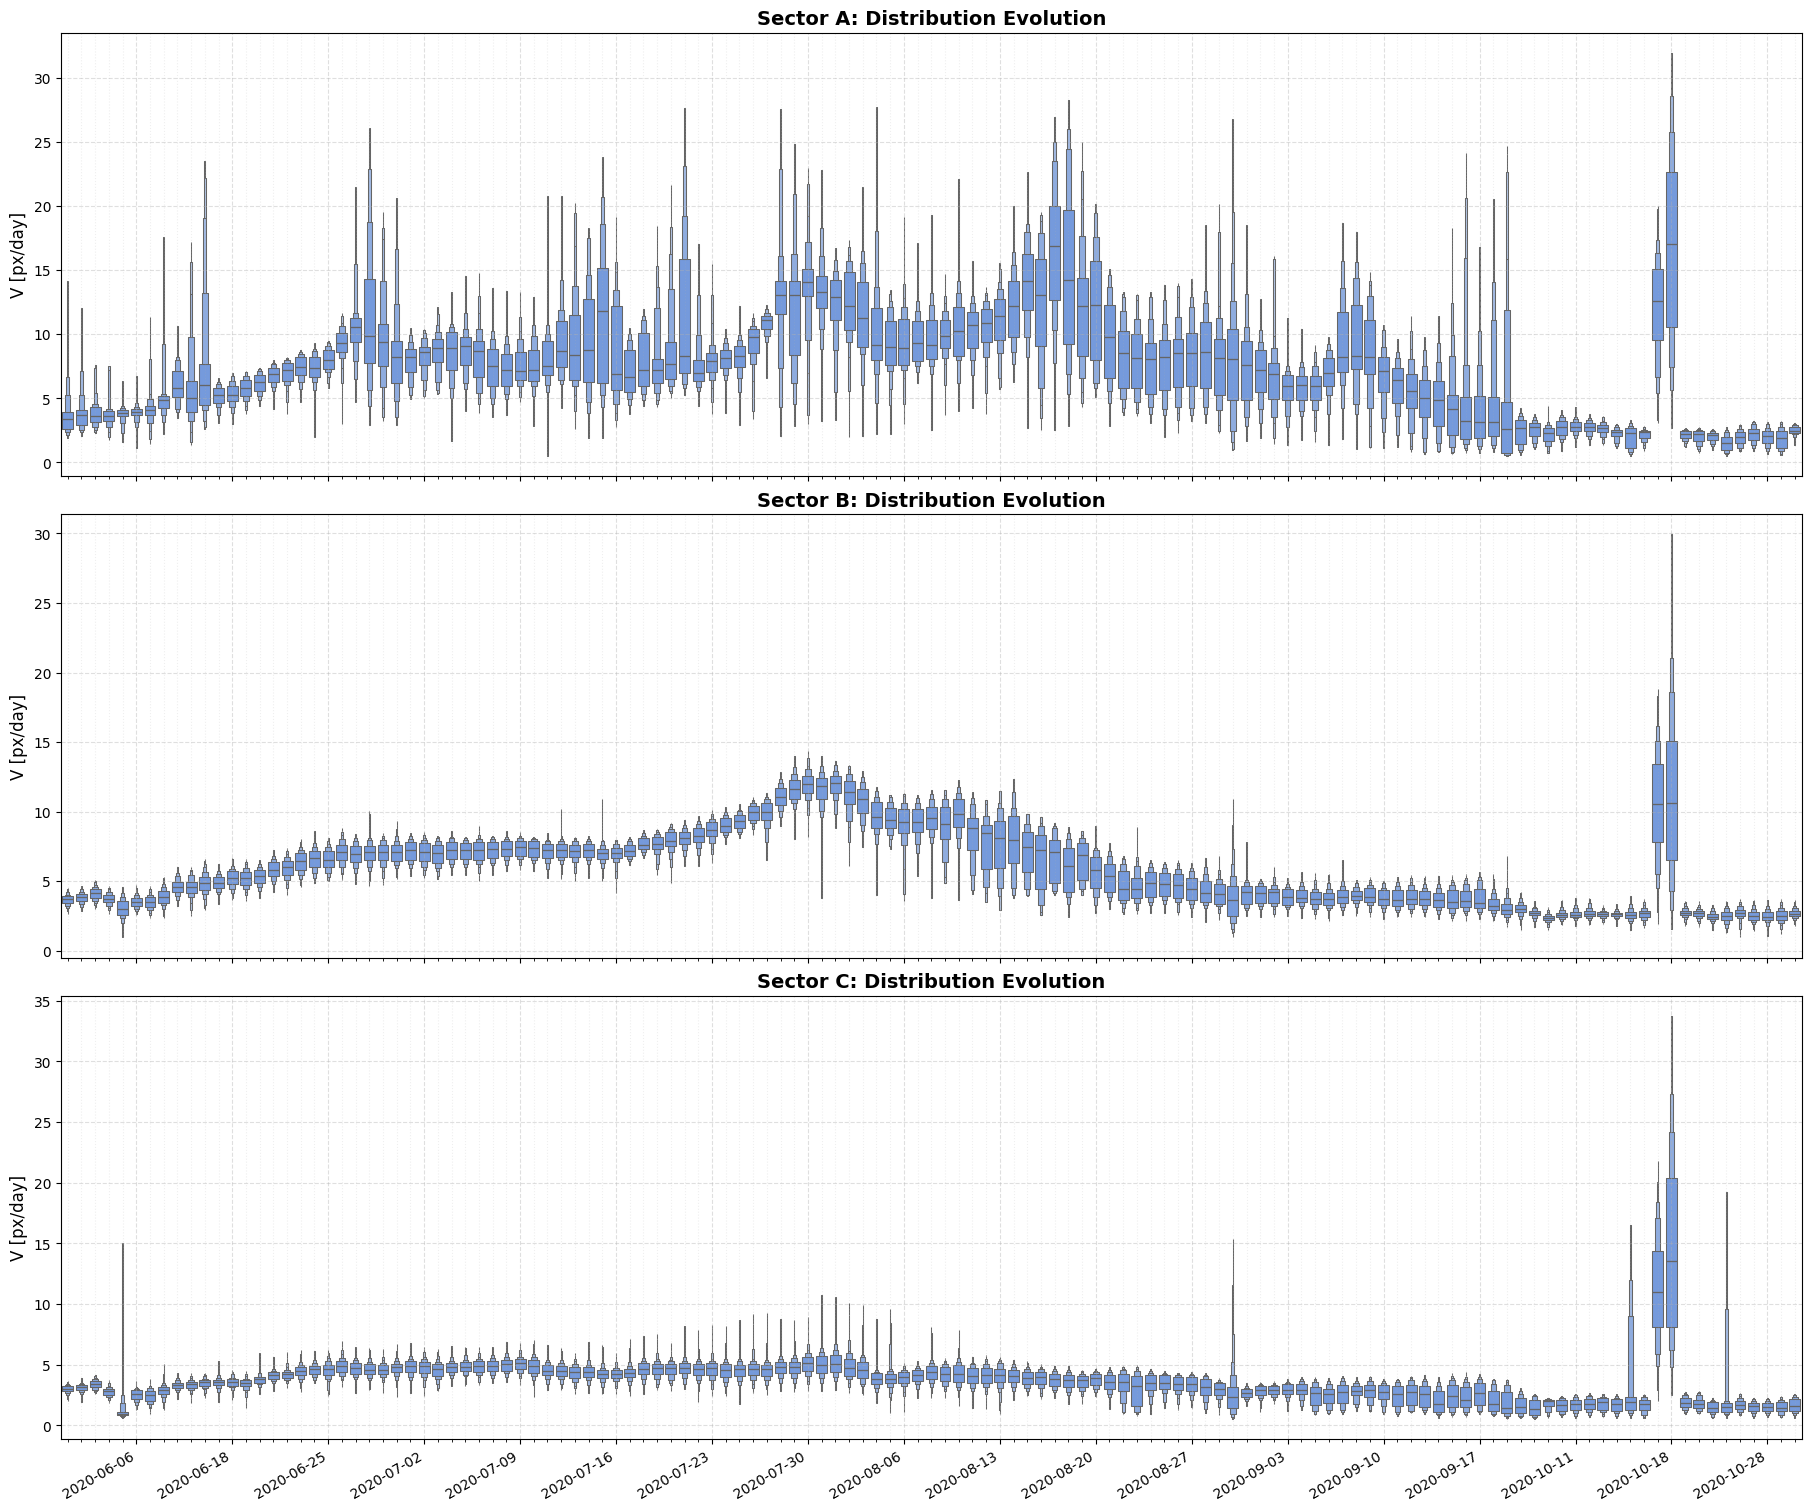

In [198]:
# --- Multi-date distribution overview: Boxen plots per sector ---

# Configuration
col = "V"  # Column to visualize (Velocity)
sectors = ["A", "B", "C"]
# sectors = sorted(df_viz["sector"].unique())

# Prepare data: ensure formatted date string for categorical plotting
df_viz = df_points_ts.copy()
n_sectors = len(sectors)

# Create a string column for the X-axis so seaborn treats it as categories (equal spacing)
# df_viz["date_str"] = df_viz["date"].dt.strftime("%Y-%m-%d")
df_viz = df_viz.sort_values(["sector", "date"])

# Create one wide subplot per sector
fig, axes = plt.subplots(
    n_sectors, 1, figsize=(18, 5 * n_sectors), constrained_layout=True
)
if n_sectors == 1:
    axes = [axes]

for ax, sector in zip(axes, sectors, strict=False):
    subset = df_viz[df_viz["sector"] == sector]

    if subset.empty:
        continue

    # Boxenplot is optimal for large datasets (shows more quantiles than a boxplot)
    # k_depth="trustworthy" ensures we don't over-plot insignificant tails
    sns.boxenplot(
        data=subset,
        x="date",
        y=col,
        ax=ax,
        color="cornflowerblue",
        showfliers=False,  # Set True to see extreme outliers, False to focus on the bulk
    )

    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    # ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_minor_locator(mdates.DayLocator())
    fig.autofmt_xdate()

    ax.set_title(f"Sector {sector}: Distribution Evolution", fontsize=14, weight="bold")
    ax.set_ylabel(f"{col} [{UNIT}/day]", fontsize=12)
    ax.set_xlabel("")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.grid(axis="x", which="minor", linestyle=":", alpha=0.2)

    # Fix X-axis labels clutter (show max ~25 dates)
    # labels = ax.get_xticklabels()
    # n_labels = len(labels)
    # step = 5
    # for i, label in enumerate(labels):
    #     if i % step != 0:
    #         label.set_visible(False)
    # plt.setp(labels, rotation=45, ha="right", rotation_mode="anchor")


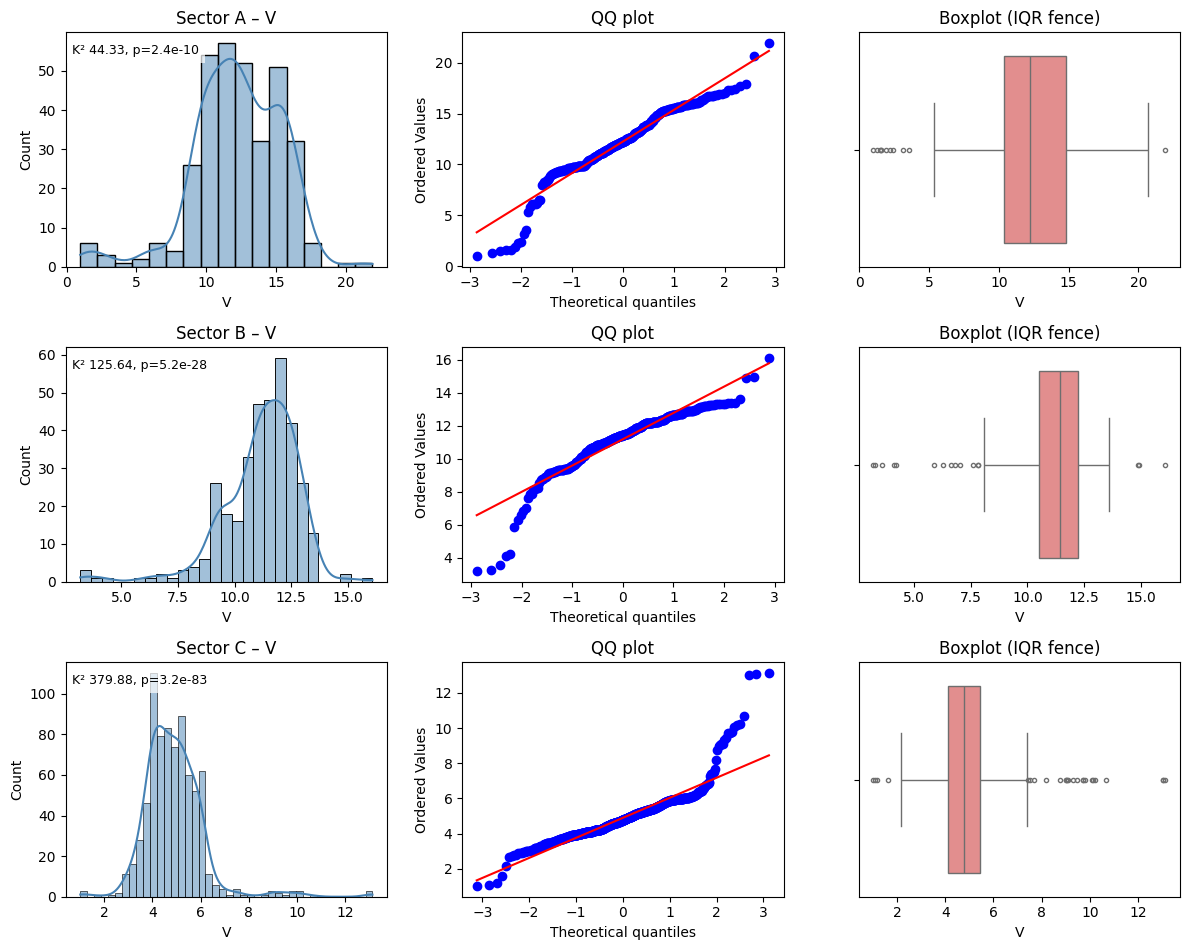

In [199]:
# --- Single-date distribution check per sector ---

date_sel = pd.to_datetime("2020-08-02")  # change as needed
col = "V"  # velocity magnitude
sectors = ["A", "B", "C"]
# sectors = sorted(df_day["sector"].unique())

df_day = df_points_ts[df_points_ts["date"] == date_sel]
if df_day.empty:
    logger.warning(f"No points for {date_sel.date()}")

n = len(sectors)
fig, axes = plt.subplots(n, 3, figsize=(12, 3.2 * n), squeeze=False)
axes = axes.reshape(n, 3)
for i, sector in enumerate(sectors):
    df_sec = df_day[df_day["sector"] == sector][col].dropna()
    ax_hist, ax_qq, ax_box = axes[i]

    # Hist + KDE
    sns.histplot(df_sec, kde=True, ax=ax_hist, color="steelblue")
    ax_hist.set_title(f"Sector {sector} – {col}")

    # QQ plot
    stats.probplot(df_sec, dist="norm", plot=ax_qq)
    ax_qq.set_title("QQ plot")

    # Boxplot (IQR outliers)
    sns.boxplot(
        x=df_sec,
        ax=ax_box,
        color="lightcoral",
        fliersize=3,
    )
    ax_box.set_title("Boxplot (IQR fence)")

    # Normality test (D’Agostino K^2; Shapiro not ideal for large n)
    if len(df_sec) >= 8:
        k2, p = stats.normaltest(df_sec)
        ax_hist.text(
            0.02,
            0.95,
            f"K² {k2:.2f}, p={p:.2}",
            transform=ax_hist.transAxes,
            va="top",
            ha="left",
            fontsize=9,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
        )

plt.tight_layout()
plt.show()


2026-01-22 16:06:27 | [INFO    ] Saved sector time series to output/2020/kinematic_sectors_time_series/sectors_time_series.png


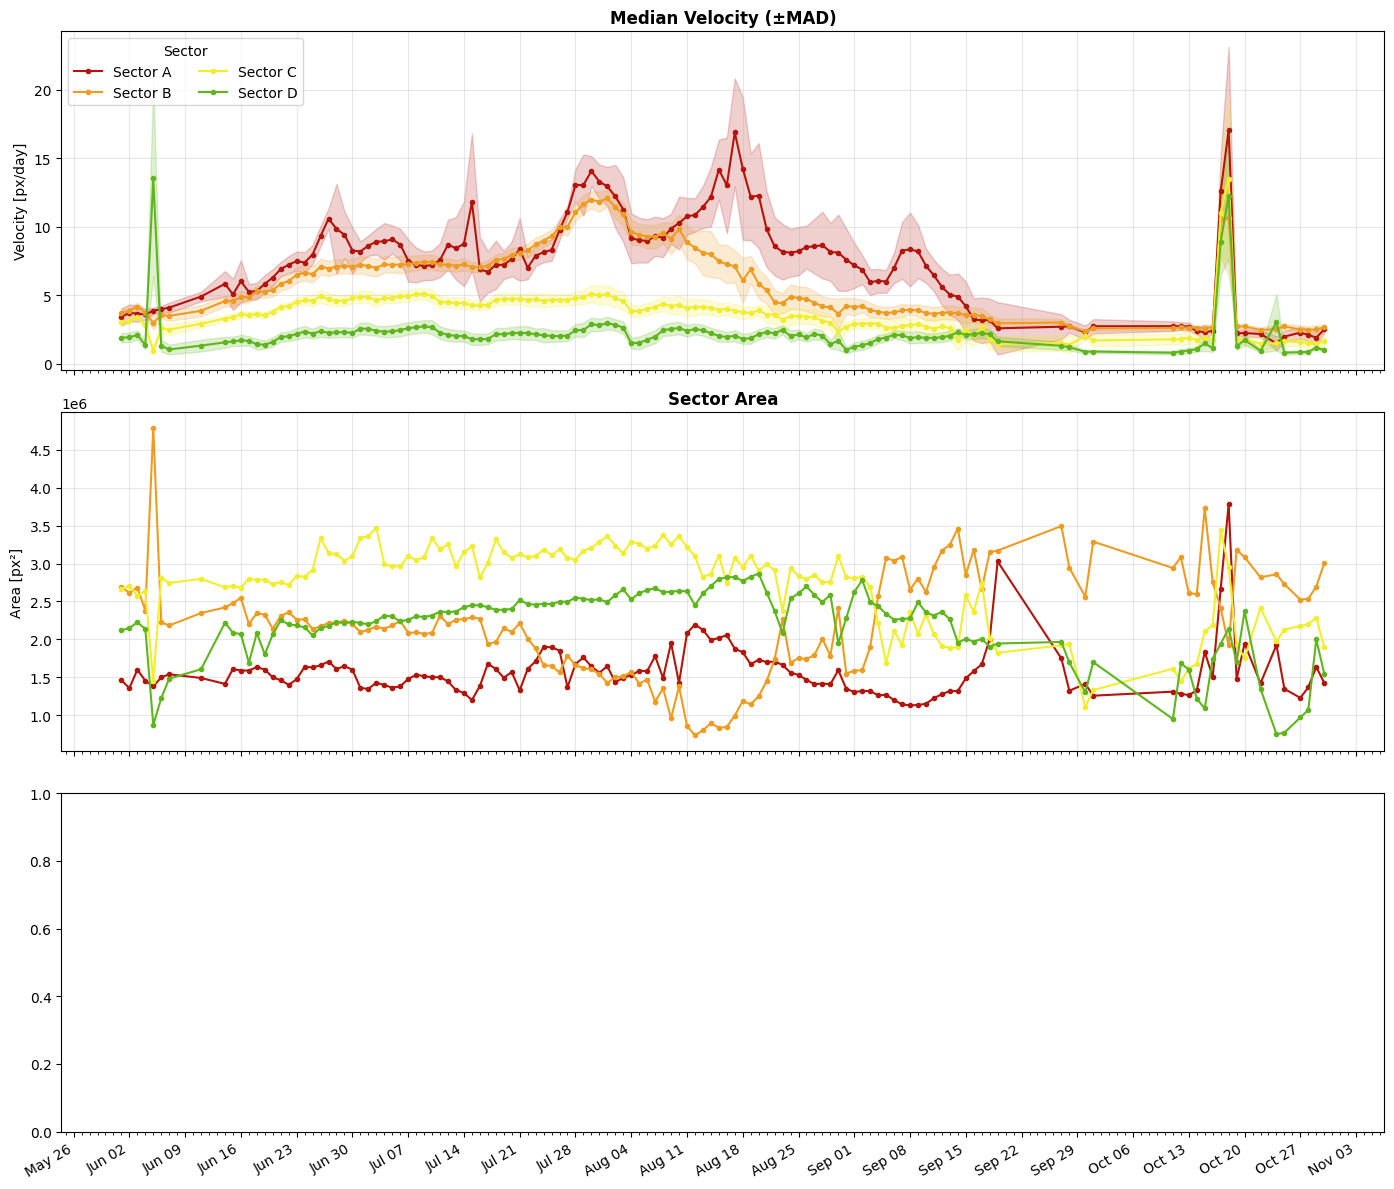

In [202]:
def plot_velocity_panel(ax, df_sectors, colors, unit: str = "px/day"):
    sectors = sorted(df_sectors["sector"].unique())
    for sector in sectors:
        subset = df_sectors[df_sectors["sector"] == sector]
        ax.plot(
            subset["date"],
            subset["v_median"],
            marker="o",
            markersize=3,
            label=f"Sector {sector}",
            color=colors.get(sector, "k"),
        )
        ax.fill_between(
            subset["date"],
            subset["v_median"] - subset["v_mad"],
            subset["v_median"] + subset["v_mad"],
            color=colors.get(sector, "k"),
            alpha=0.2,
        )
    ax.set_ylabel(f"Velocity [{unit}]")
    ax.set_title("Median Velocity (±MAD)", weight="bold")
    ax.legend(loc="upper left", title="Sector", ncol=2)
    ax.grid(True, alpha=0.3)
    return ax


def plot_area_panel(ax, df_sectors, colors, unit: str = "px²"):
    sectors = sorted(df_sectors["sector"].unique())
    for sector in sectors:
        subset = df_sectors[df_sectors["sector"] == sector]
        ax.plot(
            subset["date"],
            subset["area_px2"],
            marker="o",
            markersize=3,
            label=f"Sector {sector}",
            color=colors.get(sector, "k"),
        )
    ax.set_ylabel(f"Area [{unit}]")
    ax.set_title("Sector Area", weight="bold")
    ax.grid(True, alpha=0.3)
    return ax


def plot_velocity_separation_panel(
    ax, df_sectors, sector_pairs, rolling_days: int | None = None
):
    """
    Plots the statistical separation (Z-score) between pairs of sectors over time.
    Low values (< 1.0) indicate merging/indistinguishable velocities.

    Args:
        df_sectors: Concatenated DataFrame of sector results.
        sector_pairs: List of tuples (sector_label_1, sector_label_2).
        rolling_days: Optional window size in days for rolling average smoothing.
    """
    # fig, ax = plt.subplots(figsize=(15, 6))

    for sec1, sec2 in sector_pairs:
        # Filter data for each sector
        df1 = df_sectors[df_sectors["sector"] == sec1]
        df2 = df_sectors[df_sectors["sector"] == sec2]

        if df1.empty or df2.empty:
            continue

        # Merge on 'date' to align the time series and sort
        merged = pd.merge(
            df1, df2, on="date", suffixes=("_1", "_2"), how="inner"
        ).sort_values("date")

        if merged.empty:
            continue

        # Calculate separation (Z-score proxy)
        v1 = merged["v_median_1"].values.astype(float)
        v2 = merged["v_median_2"].values.astype(float)
        mad1 = merged["v_mad_1"].values.astype(float)
        mad2 = merged["v_mad_2"].values.astype(float)

        diff = np.abs(v1 - v2)
        noise = np.sqrt(mad1**2 + mad2**2)
        separation = np.divide(diff, noise, out=np.zeros_like(diff), where=noise != 0)

        label = f"{sec1} vs {sec2}"

        # Apply rolling average if requested
        if rolling_days is not None:
            # We use a time-aware rolling window (handles missing dates correctly)
            s_sep = pd.Series(separation, index=merged["date"])
            separation = (
                s_sep.rolling(window=f"{rolling_days}D", center=True).mean().values
            )
            label += f" ({rolling_days}d moving avg)"

        ax.plot(merged["date"], separation, label=label, marker=".", alpha=0.7)

    # Threshold for "merging"
    ax.axhline(1.0, color="r", linestyle="--", alpha=0.5, label="Non significant (Z<1)")

    ax.set_yscale("log")
    ax.set_ylabel("Velocity Separation (Z-score)")
    ax.set_title("Sector Kinematic Separation (Lower = Merging)")
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
    ax.grid(True, which="both", linestyle="--", alpha=0.3)

    # x-axis formatting
    major_locator = mdates.WeekdayLocator(interval=1)
    major_formatter = mdates.DateFormatter("%b %d")
    ax.xaxis.set_major_locator(major_locator)
    ax.xaxis.set_major_formatter(major_formatter)
    ax.xaxis.set_minor_locator(mdates.DayLocator())
    ax.grid(axis="x", which="major", linestyle="--", alpha=0.4)
    ax.grid(axis="x", which="minor", linestyle=":", alpha=0.15)

    ax.tick_params(axis="x", rotation=45)

    return ax


# Figure with time series of velocity and area of each sector

output_path = output_dir / "sectors_time_series.png"
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

sectors = sorted(df_sectors["sector"].unique())
colors = config.postprocessing.sector_assignment.get("sector_colors", {})
if not colors:
    cmap = plt.get_cmap("tab10")
    colors = {s: cmap(i % cmap.N) for i, s in enumerate(sectors)}

ax1, ax2, ax3 = axes
plot_velocity_panel(ax1, df_sectors, colors, unit=f"{UNIT}/day")
plot_area_panel(ax2, df_sectors, colors, unit=f"{UNIT}²")
# plot_velocity_separation_panel(
#     ax3, df_sectors, sector_pairs=[("A", "B"), ("B", "C")], rolling_days=5
# )

major_locator = mdates.WeekdayLocator(interval=1)
major_formatter = mdates.DateFormatter("%b %d")
for ax in axes:
    ax.xaxis.set_major_locator(major_locator)
    ax.xaxis.set_major_formatter(major_formatter)
    ax.xaxis.set_minor_locator(mdates.DayLocator())

fig.autofmt_xdate()
plt.tight_layout()

fig.savefig(output_path, dpi=300)
fig.savefig(output_path.with_suffix(".svg"), bbox_inches="tight")

logger.info(f"Saved sector time series to {output_path}")

In [203]:
df_points = df_points_ts.copy()
sec1, sec2 = "A", "B"
rolling_days = None

# Group by date to perform the test daily
dates = sorted(df_points["date"].unique())
p_values = []
valid_dates = []
for date in dates:
    # Extract velocities for the specific day and sectors
    v1 = df_points[(df_points["date"] == date) & (df_points["sector"] == sec1)][
        "V"
    ].dropna()
    v2 = df_points[(df_points["date"] == date) & (df_points["sector"] == sec2)][
        "V"
    ].dropna()

    # Filter out outliers (>+-0.05 percentile)

    # Need minimal data points to run the test
    if len(v1) < 5 or len(v2) < 5:
        continue

    # Mann-Whitney U Test
    # alternative='two-sided' checks if distributions are different
    try:
        stat, p = stats.mannwhitneyu(v1, v2, alternative="two-sided")
        p_values.append(p)
        valid_dates.append(date)
    except ValueError:
        continue

if not valid_dates:
    logger.warning(f"No valid data to test separation for {sec1} vs {sec2}")

# Convert to numpy array for processing
p_values = np.array(p_values)

# Avoid log(0)
p_values = np.where(p_values == 0, 1e-300, p_values)

label = f"{sec1} vs {sec2}"

# Plot -log10(p-value) for better visualization
# High value = High significance (Separated)
# Low value = Low significance (Merged/Same)
significance_score = -np.log10(p_values)

if rolling_days is not None:
    s_sig = pd.Series(significance_score, index=valid_dates)
    significance_score = (
        s_sig.rolling(window=f"{rolling_days}D", center=True).median().values
    )
    label += f" ({rolling_days}d median)"

In [204]:
significance_score


array([1.00477812e+01, 4.64740788e+00, 2.01231239e+01, 5.64734180e+00,
       5.13519447e+01, 2.94429279e+01, 3.40463897e+01, 4.96697471e+01,
       5.19088197e+01, 5.56384731e+00, 2.13090986e+01, 9.78587823e+00,
       1.68108231e+00, 2.31859783e+01, 4.66370651e+01, 6.26964001e+01,
       5.76980289e+01, 4.82453648e+01, 3.07007489e+01, 8.21698788e+01,
       1.08440879e+02, 1.05603997e+02, 4.72345194e+01, 5.05365825e+01,
       1.56137022e+01, 2.26533008e+01, 4.17781745e+01, 5.45347121e+01,
       2.85663417e+01, 4.13848086e+01, 2.37697430e+01, 1.15655956e+00,
       7.20668023e-02, 6.23103879e-02, 3.21575133e-01, 9.81475493e+00,
       3.73957545e+01, 1.45334272e+01, 1.07124324e+01, 1.82017069e+01,
       4.08149223e-02, 3.79537450e+00, 2.87990358e+00, 9.17321359e+00,
       1.77390136e+00, 3.81507985e+00, 3.38860833e+01, 2.84697798e+01,
       3.77991698e+01, 4.14247213e+01, 4.48822146e+00, 4.39760739e+01,
       3.75999427e+01, 5.80598802e+00, 4.92728759e+01, 3.19983030e+01,
      

(array([18408., 18415., 18422., 18429., 18436., 18443., 18450., 18457.,
        18464., 18471., 18478., 18485., 18492., 18499., 18506., 18513.,
        18520., 18527., 18534., 18541., 18548., 18555., 18562., 18569.]),
 [Text(18408.0, 0, 'May 26'),
  Text(18415.0, 0, 'Jun 02'),
  Text(18422.0, 0, 'Jun 09'),
  Text(18429.0, 0, 'Jun 16'),
  Text(18436.0, 0, 'Jun 23'),
  Text(18443.0, 0, 'Jun 30'),
  Text(18450.0, 0, 'Jul 07'),
  Text(18457.0, 0, 'Jul 14'),
  Text(18464.0, 0, 'Jul 21'),
  Text(18471.0, 0, 'Jul 28'),
  Text(18478.0, 0, 'Aug 04'),
  Text(18485.0, 0, 'Aug 11'),
  Text(18492.0, 0, 'Aug 18'),
  Text(18499.0, 0, 'Aug 25'),
  Text(18506.0, 0, 'Sep 01'),
  Text(18513.0, 0, 'Sep 08'),
  Text(18520.0, 0, 'Sep 15'),
  Text(18527.0, 0, 'Sep 22'),
  Text(18534.0, 0, 'Sep 29'),
  Text(18541.0, 0, 'Oct 06'),
  Text(18548.0, 0, 'Oct 13'),
  Text(18555.0, 0, 'Oct 20'),
  Text(18562.0, 0, 'Oct 27'),
  Text(18569.0, 0, 'Nov 03')])

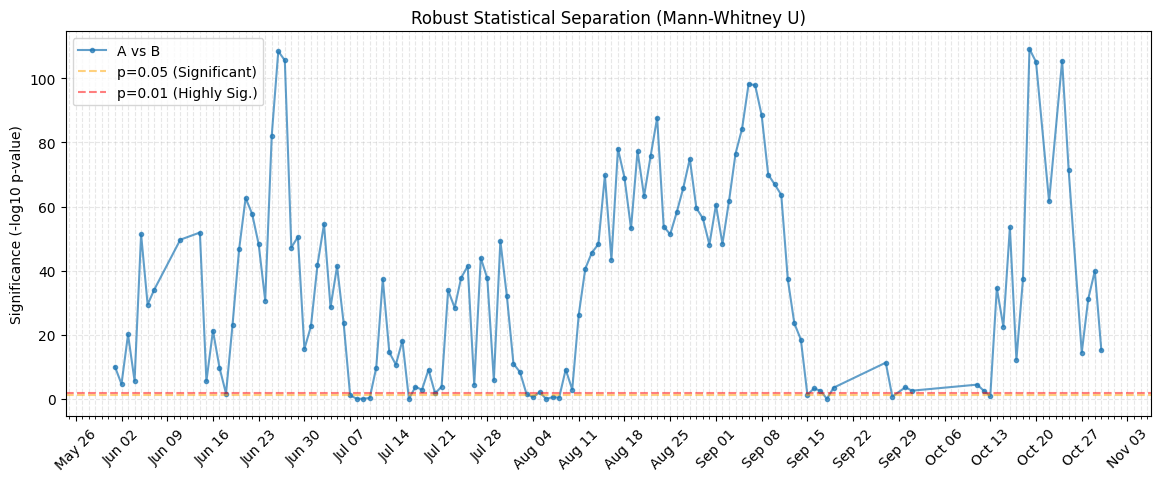

In [205]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(valid_dates, significance_score, label=label, marker=".", alpha=0.7)

# Threshold lines
# p = 0.05 -> -log10(0.05) ~= 1.3
# p = 0.01 -> -log10(0.01) = 2.0
ax.axhline(1.3, color="orange", linestyle="--", alpha=0.5, label="p=0.05 (Significant)")
ax.axhline(2.0, color="red", linestyle="--", alpha=0.5, label="p=0.01 (Highly Sig.)")

ax.set_ylabel("Significance (-log10 p-value)")
ax.set_title("Robust Statistical Separation (Mann-Whitney U)")
ax.legend(loc="upper left")
ax.grid(True, which="both", linestyle="--", alpha=0.3)

# x-axis formatting
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_minor_locator(mdates.DayLocator())
plt.xticks(rotation=45)


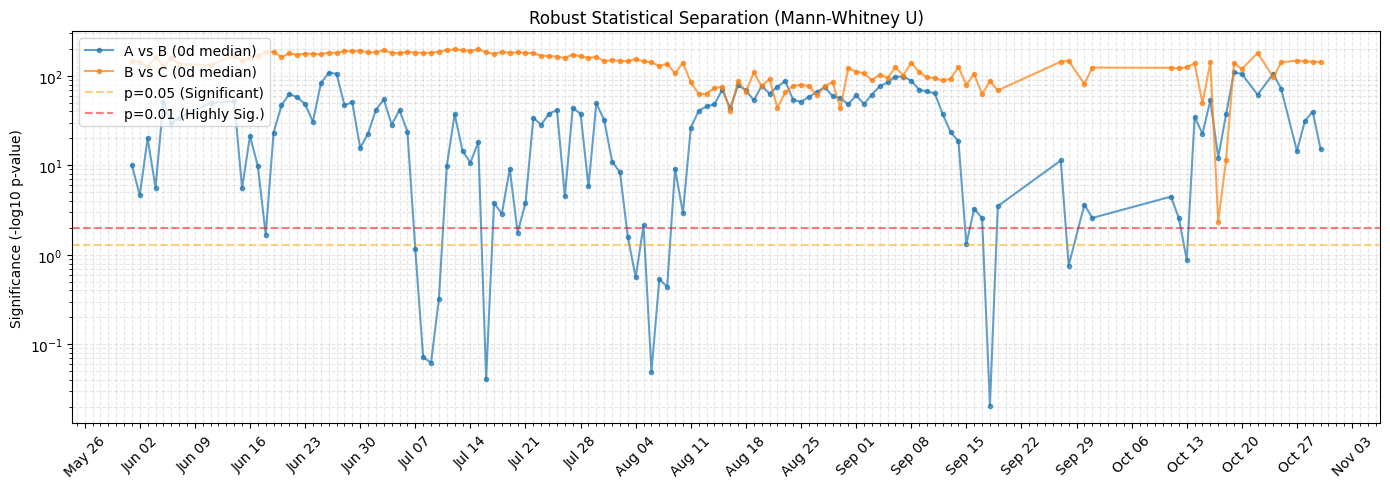

In [206]:
def plot_robust_velocity_separation(
    ax, df_points, sector_pairs, rolling_days: int | None = None
):
    """
    Plots the statistical separation (p-value) between pairs of sectors using
    the Mann-Whitney U test, which is robust to non-normal data and outliers.
    """
    for sec1, sec2 in sector_pairs:
        # Group by date to perform the test daily
        dates = sorted(df_points["date"].unique())
        p_values = []
        valid_dates = []

        for date in dates:
            # Extract velocities for the specific day and sectors
            v1 = df_points[(df_points["date"] == date) & (df_points["sector"] == sec1)][
                "V"
            ].dropna()

            v2 = df_points[(df_points["date"] == date) & (df_points["sector"] == sec2)][
                "V"
            ].dropna()

            # Need minimal data points to run the test
            if len(v1) < 5 or len(v2) < 5:
                continue

            # Mann-Whitney U Test
            # alternative='two-sided' checks if distributions are different
            try:
                stat, p = stats.mannwhitneyu(v1, v2, alternative="two-sided")
                p_values.append(p)
                valid_dates.append(date)
            except ValueError:
                continue

        if not valid_dates:
            logger.warning(f"No valid data to test separation for {sec1} vs {sec2}")
            continue

        # Convert to numpy array for processing
        p_values = np.array(p_values)

        # Avoid log(0)
        p_values = np.where(p_values == 0, 1e-300, p_values)

        label = f"{sec1} vs {sec2}"

        # Plot -log10(p-value) for better visualization
        # High value = High significance (Separated)
        # Low value = Low significance (Merged/Same)
        significance_score = -np.log10(p_values)

        if rolling_days is not None:
            s_sig = pd.Series(significance_score, index=valid_dates)
            significance_score = (
                s_sig.rolling(window=f"{rolling_days}D", center=True).median().values
            )
            label += f" ({rolling_days}d median)"

        ax.plot(valid_dates, significance_score, label=label, marker=".", alpha=0.7)

    # Threshold lines
    # p = 0.05 -> -log10(0.05) ~= 1.3
    # p = 0.01 -> -log10(0.01) = 2.0
    ax.axhline(
        1.3, color="orange", linestyle="--", alpha=0.5, label="p=0.05 (Significant)"
    )
    ax.axhline(
        2.0, color="red", linestyle="--", alpha=0.5, label="p=0.01 (Highly Sig.)"
    )

    ax.set_yscale("log")

    ax.set_ylabel("Significance (-log10 p-value)")
    ax.set_title("Robust Statistical Separation (Mann-Whitney U)")
    ax.legend(loc="upper left")
    ax.grid(True, which="both", linestyle="--", alpha=0.3)

    # x-axis formatting
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_minor_locator(mdates.DayLocator())
    plt.xticks(rotation=45)

    return ax


fig, ax = plt.subplots(figsize=(14, 5))
plot_robust_velocity_separation(
    ax,
    df_points_ts,
    sector_pairs=[("A", "B"), ("B", "C")],
    rolling_days=0,
)
plt.tight_layout()
plt.show()


In [207]:
sectors = sorted(df_sectors["sector"].unique())

sec1, sec2 = "A", "B"
rolling_days = 5

# Filter data for each sector
df1 = df_sectors[df_sectors["sector"] == sec1]
df2 = df_sectors[df_sectors["sector"] == sec2]

# Merge on 'date' to align the time series and sort
merged = pd.merge(df1, df2, on="date", suffixes=("_1", "_2"), how="inner").sort_values(
    "date"
)

# Calculate separation (Z-score proxy)
mu1 = merged["v_mean_1"].values.astype(float)
mu2 = merged["v_mean_2"].values.astype(float)
sigma1 = merged["v_std_1"].values.astype(float)
sigma2 = merged["v_std_2"].values.astype(float)

In [208]:
diff = np.abs(mu1 - mu2)
noise = np.sqrt(sigma1**2 + sigma2**2)
separation = np.divide(diff, noise, out=np.zeros_like(diff), where=noise != 0)

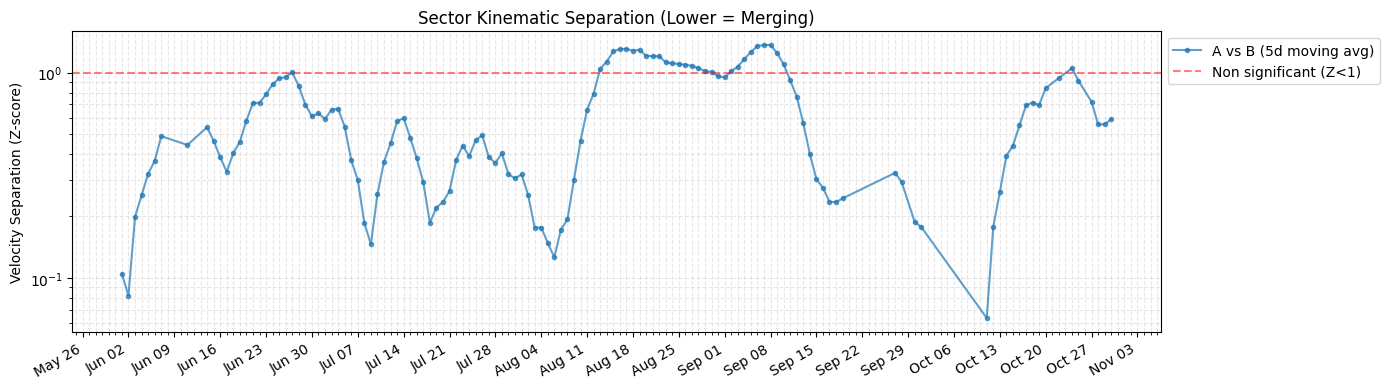

In [209]:
fig, ax = plt.subplots(1, 1, figsize=(14, 4))

label = f"{sec1} vs {sec2}"

# Apply rolling average if requested
if rolling_days is not None:
    # We use a time-aware rolling window (handles missing dates correctly)
    s_sep = pd.Series(separation, index=merged["date"])
    separation = s_sep.rolling(window=f"{rolling_days}D", center=True).mean().values
    label += f" ({rolling_days}d moving avg)"


ax.plot(merged["date"], separation, label=label, marker=".", alpha=0.7)

# Threshold for "merging"
ax.axhline(1.0, color="r", linestyle="--", alpha=0.5, label="Non significant (Z<1)")

ax.set_yscale("log")
ax.set_ylabel("Velocity Separation (Z-score)")
ax.set_title("Sector Kinematic Separation (Lower = Merging)")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
ax.grid(True, which="both", linestyle="--", alpha=0.3)


ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_minor_locator(mdates.DayLocator())
fig.autofmt_xdate()

plt.tight_layout()


2026-01-22 16:06:42 | [INFO    ] Using fixed area bin size 1000000: bins [      0. 1000000. 2000000. 3000000. 4000000. 5000000.]


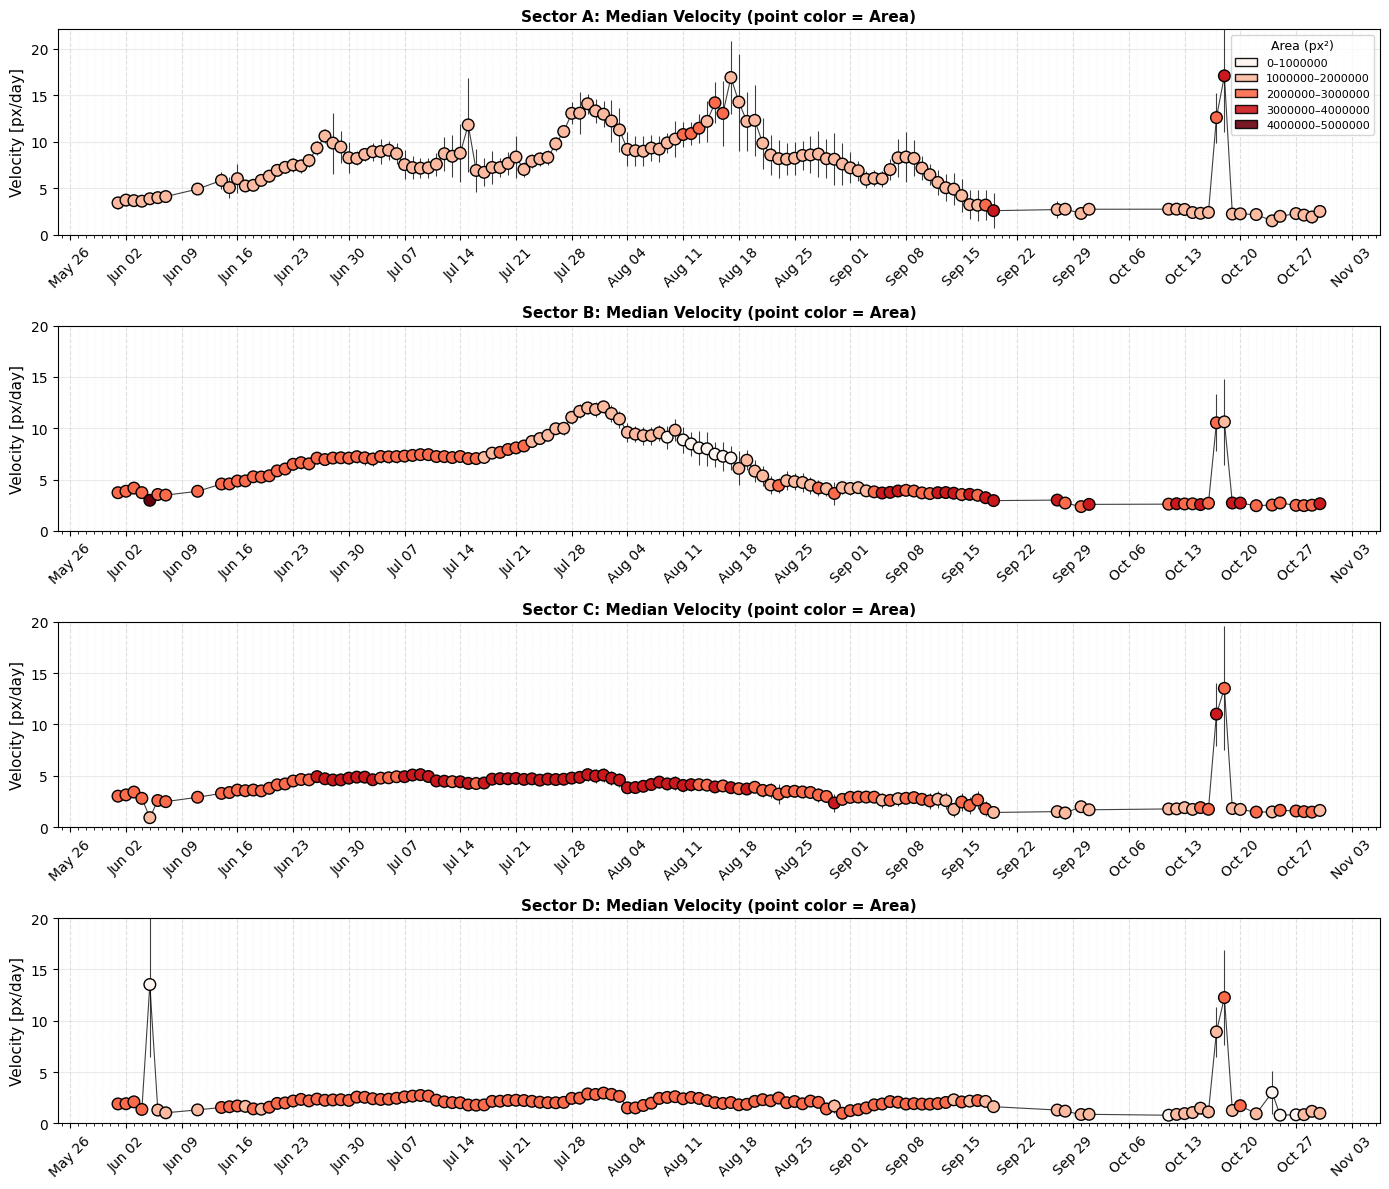

In [210]:
# Combined plot velocity-area for each sector separately (one panel per sector)

output_path = output_dir / "sectors_velocity_area_time_series.png"

# --- User-configurable binning options ---
# Option A: fixed integer bin size (px^2). Example: 500_000
area_bin_size: int | None = 1_000_000  # set to None to disable this option

# Option B: explicit bin edges list (overrides bin size if provided)
area_bin_edges: list[float] | None = None  # e.g. [0, 5e5, 1e6, 2e6]

# Fallback: number of evenly spaced bins if neither option is set
fallback_n_bins = 5

# compute global area range (ignore NaNs) using the DataFrame column
if df_sectors.empty or "area_px2" not in df_sectors.columns:
    all_areas = np.array([])
else:
    all_areas = df_sectors["area_px2"].dropna().values.astype(float)

if all_areas.size == 0:
    min_a, max_a = 0.0, 1.0
else:
    min_a, max_a = float(np.min(all_areas)), float(np.max(all_areas))
    if np.isclose(min_a, max_a):
        max_a = min_a + 1.0

# Decide bins using a simple, clear approach:
if area_bin_edges is not None:
    bins = np.asarray(area_bin_edges, dtype=float)
    logger.info(f"Using user-provided area bin edges: {bins}")
elif area_bin_size:
    # round min/max to multiples of bin size to make clean integer bins
    start = np.floor(min_a / area_bin_size) * area_bin_size
    stop = np.ceil(max_a / area_bin_size) * area_bin_size
    if start == stop:
        stop = start + area_bin_size
    bins = np.arange(start, stop + area_bin_size, area_bin_size)
    logger.info(f"Using fixed area bin size {area_bin_size}: bins {bins}")
else:
    bins = np.linspace(min_a, max_a, fallback_n_bins + 1)
    logger.info(f"Using fallback linear bins (n={fallback_n_bins}): {bins}")

n_bins = max(1, len(bins) - 1)
cmap = plt.get_cmap("Reds", n_bins)
colors_list = [cmap(i) for i in range(n_bins)]

# Get unique sectors
sectors = sorted(df_sectors["sector"].unique())
n_sectors = len(sectors)

fig, axes = plt.subplots(
    min(4, n_sectors),
    1,
    figsize=(14, 3 * min(4, n_sectors)),
    squeeze=False,
)
axes = axes.flatten()

# create legend patches for area bins (one-time)
area_patches = []
for i in range(n_bins):
    low, high = bins[i], bins[i + 1]
    label = f"{low:.0f}–{high:.0f}"
    area_patches.append(
        Patch(facecolor=colors_list[i], edgecolor="k", label=label, alpha=0.9)
    )

for ax, sector in zip(axes, sectors, strict=False):
    # Filter DataFrame for the specific sector and sort by date
    subset = df_sectors[df_sectors["sector"] == sector].sort_values("date")

    dates_dt = subset["date"]
    v_median = subset["v_median"].to_numpy(dtype=float)
    v_mad = subset["v_mad"].to_numpy(dtype=float)
    area = subset["area_px2"].to_numpy(dtype=float)

    # bin areas into discrete colors using numpy.digitize
    safe_area = np.nan_to_num(area, nan=bins[0])
    bin_idx = np.digitize(safe_area, bins) - 1  # index in 0..n_bins-1
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)
    colors_area = [colors_list[i] for i in bin_idx]

    ax.errorbar(
        dates_dt,
        v_median,
        yerr=v_mad,
        markersize=0,
        linestyle="-",
        linewidth=0.8,
        label=f"Sector {sector}",
        color="k",
        alpha=0.75,
    )
    ax.scatter(
        dates_dt,
        v_median,
        s=70,
        c=colors_area,
        edgecolors="k",
        zorder=3,
    )

    ax.set_ylabel(f"Velocity [{UNIT}/day]", fontsize=11)
    ax.set_title(
        f"Sector {sector}: Median Velocity (point color = Area)",
        fontsize=11,
        weight="bold",
    )
    ax.grid(axis="y", alpha=0.25)

    # x-axis formatting
    major_locator = mdates.WeekdayLocator(interval=1)
    major_formatter = mdates.DateFormatter("%b %d")
    ax.xaxis.set_major_locator(major_locator)
    ax.xaxis.set_major_formatter(major_formatter)
    ax.xaxis.set_minor_locator(mdates.DayLocator())
    ax.grid(axis="x", which="major", linestyle="--", alpha=0.4)
    ax.grid(axis="x", which="minor", linestyle=":", alpha=0.15)

    ax.tick_params(axis="x", rotation=45)

    # Optional: consistent y-limits for better comparison
    if len(v_median) > 0:
        ax.set_ylim([0, max(20, np.nanmax(v_median) + 5)])  # simple, avoids tiny ranges

# place area color legend in the first axis (clear and compact)
if axes.size > 0:
    axes[0].legend(
        handles=area_patches,
        title=f"Area ({UNIT}²)",
        loc="best",
        fontsize=8,
        title_fontsize=9,
    )

fig.tight_layout()

fig.savefig(output_path, dpi=300, bbox_inches="tight")
fig.savefig(output_path.with_suffix(".svg"), bbox_inches="tight")

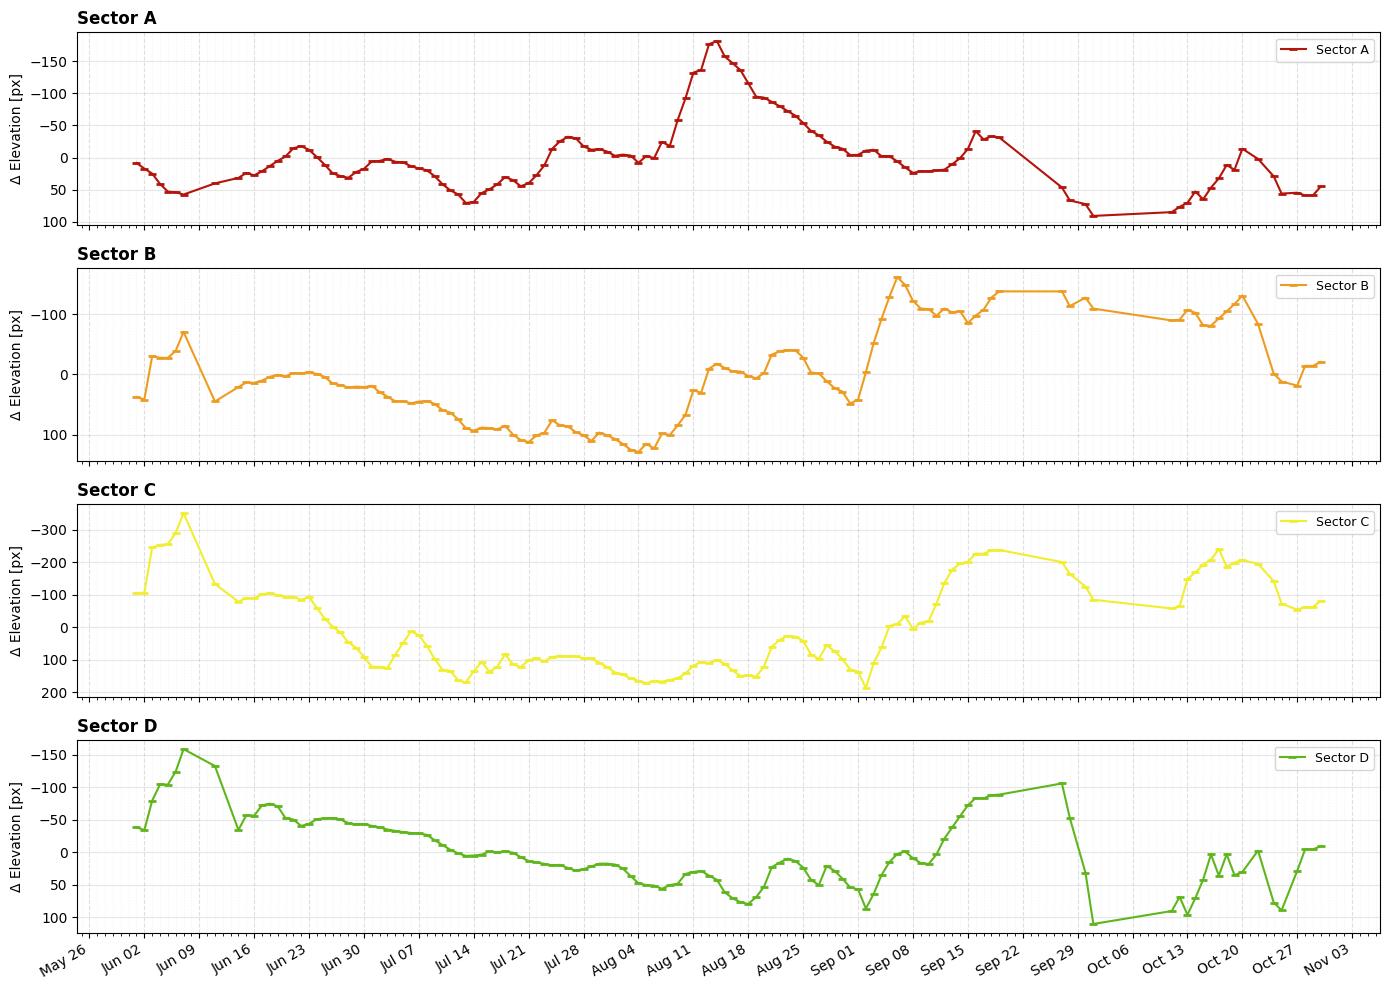

In [211]:
# Swimmer plot: vertical movement of sectors' centroid over time
def plot_swimmer_single_sector(
    ax,
    df_sector: pd.DataFrame,
    sector_label: str,
    color: str,
    plot_sector_extent: bool = True,
    subtract_mean: bool = True,
):
    """
    Plot the vertical movement (centroid & extent) for a single sector.

    Args:
        ax: Matplotlib axis to draw on
        df_sector: DataFrame containing data for ONE sector only (already filtered)
        sector_label: Label/name of the sector (for legend)
        color: Color to use for this sector
        subtract_mean: If True, plot relative to mean elevation (highlights movement)

    Returns:
        ax: The modified axis
    """
    # Check for required columns
    if "centroid_y" not in df_sector.columns:
        ax.text(
            0.5,
            0.5,
            "No spatial geometry data available",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        return ax

    # Filter and sort
    subset = (
        df_sector.dropna(subset=["centroid_y", "min_y", "max_y"])
        .sort_values("date")
        .copy()
    )

    if subset.empty:
        ax.text(
            0.5,
            0.5,
            f"No valid data for Sector {sector_label}",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        return ax

    # Optionally subtract mean to show relative movement
    if subtract_mean:
        mean_y = subset["centroid_y"].mean()
        subset["centroid_y"] = subset["centroid_y"] - mean_y
        subset["min_y"] = subset["min_y"] - mean_y
        subset["max_y"] = subset["max_y"] - mean_y

    # Plot vertical extent (range bars)
    if plot_sector_extent:
        ax.vlines(
            subset["date"],
            subset["min_y"],
            subset["max_y"],
            color=color,
            alpha=0.2,
            linewidth=2,
            label=f"Sector {sector_label} Extent" if sector_label else None,
        )

    # Plot centroid trajectory
    ax.plot(
        subset["date"],
        subset["centroid_y"],
        marker="_",
        markersize=6,
        mew=2,
        linestyle="-",
        linewidth=1.5,
        color=color,
        label=f"Sector {sector_label}",
    )

    return ax


def plot_swimmer_all_sectors(
    df_sectors: pd.DataFrame,
    colors: dict,
    plot_sector_extent: bool = True,
    subtract_mean: bool = True,
    rolling_days: int | None = None,
):
    """
    Create swimmer plot(s) for all sectors.

    Args:
        df_sectors: Full DataFrame with all sectors and dates
        colors: Dict mapping sector labels to colors
        plot_sector_extent: If True, plot vertical extent bars for each sector
        subtract_mean: If True, center each sector around its mean elevation
        rolling_days: If provided, apply rolling mean smoothing over this many days

    Returns:
        fig: The matplotlib figure
    """
    sectors = sorted(df_sectors["sector"].unique())
    n_sectors = len(sectors)

    if n_sectors == 0:
        return None

    # Create figure layout
    fig, axes = plt.subplots(
        nrows=n_sectors, ncols=1, figsize=(14, 10), sharex=True, squeeze=False
    )
    axes_flat = axes.flatten()

    # Plot each sector
    for idx, sector in enumerate(sectors):
        ax = axes_flat[idx]
        df_sector = df_sectors[df_sectors["sector"] == sector]
        color = colors.get(sector, "k")

        # Apply rolling mean smoothing to centroid and extent columns
        if rolling_days is not None:
            df_sector = df_sector.sort_values("date").copy()
            for col in ["centroid_y", "min_y", "max_y"]:
                s_col = pd.Series(df_sector[col].values, index=df_sector["date"])
                df_sector[col] = (
                    s_col.rolling(window=f"{rolling_days}D", center=True).mean().values
                )

        plot_swimmer_single_sector(
            ax,
            df_sector,
            sector_label=sector,
            color=color,
            plot_sector_extent=plot_sector_extent,
            subtract_mean=subtract_mean,
        )

        # Styling for individual panels
        y_label = "Δ Elevation [px]" if subtract_mean else "Elevation [px]"
        ax.set_ylabel(y_label)
        ax.set_title(f"Sector {sector}", weight="bold", loc="left")
        ax.invert_yaxis()
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper right", fontsize=9)

        major_locator = mdates.WeekdayLocator(interval=1)
        major_formatter = mdates.DateFormatter("%b %d")
        ax.xaxis.set_major_locator(major_locator)
        ax.xaxis.set_major_formatter(major_formatter)
        ax.xaxis.set_minor_locator(mdates.DayLocator())
        ax.grid(axis="x", which="major", linestyle="--", alpha=0.4)
        ax.grid(axis="x", which="minor", linestyle=":", alpha=0.15)

    fig.autofmt_xdate()
    plt.tight_layout()

    return fig


# Separate panels (one row per sector)
fig_separate = plot_swimmer_all_sectors(
    df_sectors,
    colors,
    plot_sector_extent=False,
    subtract_mean=True,
    rolling_days=5,
)
fig_separate.savefig(output_dir / "sectors_centroid_location.png", dpi=300)

In [ ]:
from joblib import Parallel, delayed
from tqdm import tqdm

from ppcluster.sectors import plot_sectors


def _render_mosaic_chunk(
    part_idx: int,
    date_chunk,
    df_sectors,
    colors,
    output_base_path: Path,
    ncols: int,
    nrows: int | None,
    image: Any = None,
    df_points: pd.DataFrame | None = None,
    save_svg: bool = False,
):
    # allow user override of nrows; otherwise auto-compute
    n_dates = len(date_chunk)
    rows = nrows if nrows else int(np.ceil(n_dates / ncols))

    fig, axes = plt.subplots(
        rows, ncols, figsize=(4 * ncols, 4 * rows), constrained_layout=True
    )
    axes_flat = axes.flatten()

    for idx, date in tqdm(
        enumerate(date_chunk),
        desc=f"Rendering chunk {part_idx}",
        total=n_dates,
        leave=False,
        position=1,
    ):
        ax = axes_flat[idx]
        daily_gdf = gpd.GeoDataFrame(df_sectors[df_sectors["date"] == date])

        if daily_gdf.empty:
            ax.axis("off")
            continue

        plot_sectors(
            sectors=daily_gdf,
            img=image,
            velocity_df=df_points,
            sector_colors=colors,
            add_sector_labels=False,
            title=date.strftime("%Y-%m-%d"),
            ax=ax,
        )

        # Remove individual legends except for the very first plot in the mosaic
        is_first = part_idx == 1 and idx == 0
        if not is_first:
            legend = ax.get_legend()
            if legend:
                legend.remove()

        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.invert_yaxis()

    for i in range(n_dates, len(axes_flat)):
        axes_flat[i].axis("off")

    plt.suptitle(
        f"Sectors Geometric Evolution (Part {part_idx})", fontsize=20, weight="bold"
    )

    suffix = f"_part{part_idx}" if len(date_chunk) else ""
    out_path = output_base_path.with_name(f"{output_base_path.stem}{suffix}.jpg")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    if save_svg:
        fig.savefig(out_path.with_suffix(".svg"), bbox_inches="tight")

    plt.close(fig)
    logger.info(f"Saved mosaic: {out_path}")


def create_sectors_evolution_mosaic(
    df_sectors: pd.DataFrame,
    output_base_path: Path,
    df_points: pd.DataFrame | None = None,
    image: Any = None,
    max_dates_per_figure: int = 24,
    ncols: int = 6,
    nrows: int | None = None,
    save_svg: bool = False,
    n_jobs: int = 2,
):
    unique_dates = sorted(df_sectors["date"].unique())
    n_total_dates = len(unique_dates)

    sectors_list = sorted(df_sectors["sector"].unique())
    try:
        colors = config.postprocessing.sector_assignment.get("sector_colors", {})
    except Exception:
        logger.warning("Unable to get sector colors from config file")
        colors = None
    if not colors:
        cmap = plt.get_cmap("tab10")
        colors = {s: cmap(i % cmap.N) for i, s in enumerate(sectors_list)}

    # Creating chunks
    chunks = [
        unique_dates[i : i + max_dates_per_figure]
        for i in range(0, n_total_dates, max_dates_per_figure)
    ]
    logger.info(f"Created {len(chunks)} chunks for mosaic plotting")

    logger.info("Starting parallel plotting of mosaic chunks... ")
    Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(_render_mosaic_chunk)(
            part_idx,
            date_chunk,
            df_sectors,
            colors,
            output_base_path,
            ncols,
            nrows,
            image,
            df_points,
            save_svg,
        )
        for part_idx, date_chunk in tqdm(
            enumerate(chunks, 1),
            desc="Plotting figures in parallel",
            total=len(chunks),
            position=0,
        )
    )
    logger.info("Completed mosaic plotting.")


# Generate mosaic for all available data
output_path_mosaic = output_dir / "sectors_evolution_mosaic"
create_sectors_evolution_mosaic(
    df_sectors,
    output_path_mosaic,
    image=None,
    df_points=None,
    max_dates_per_figure=30,
    ncols=6,
    nrows=None,
    save_svg=False,
    n_jobs=5,
)

2026-01-22 16:06:51 | [INFO    ] Created 5 chunks for mosaic plotting
2026-01-22 16:06:51 | [INFO    ] Starting parallel plotting of mosaic chunks... 
Plotting figures in parallel: 100%|██████████| 5/5 [00:00<00:00, 246.65it/s]

Rendering chunk 5: 100%|██████████| 7/7 [00:05<00:00,  1.33it/s]
                                                                
Rendering chunk 4:  77%|███████▋  | 23/30 [00:42<00:09,  1.36s/it]

Rendering chunk 3: 100%|██████████| 30/30 [00:46<00:00,  1.05it/s]
                                                                  
Rendering chunk 1: 100%|██████████| 30/30 [00:48<00:00,  1.01it/s]
                                                                  
Rendering chunk 2: 100%|██████████| 30/30 [00:48<00:00,  1.01it/s]
                                                                  
Rendering chunk 4: 100%|██████████| 30/30 [00:49<00:00,  1.00s/it]
                                                                  2026-01-22 16:07:44 | [INFO    ] Compl